<img alt="FinanceScenarios" src="/assets/images/projects/financescenarios/banner.png" width="100%" />


# FinanceScenarios -- 2. Regimes

> "What if things go wrong in a specific way?" A stress *regime* tells
> a story, such as an oil crisis, and shows how the whole economy would look if that story played out.

A regime is a small text file (YAML) that ships with the package. It does one or both of two things:

- **Beliefs** change an assumption *before* simulating, for example "inflation rises to 9% within a year"
  (a *belief override*).
- **Targets** keep only the scenarios that fit the story *after* simulating, for example "the worst 20% for stocks".

This notebook starts with the one-line way, then shows each shape in turn. See the [regime documentation](https://www.jeroenbouma.com/projects/financescenarios/docs/regimes) for every field.

In [1]:
import polars as pl

from financescenarios import Scenarios, compare_runs, list_presets

pl.Config.set_tbl_width_chars(200)  # wide enough that long factor names are not wrapped
pl.Config.set_fmt_str_lengths(80)
pl.Config.set_tbl_rows(30)
list_presets(kind="regimes")

kind,id,use_with,name,description
str,str,str,str,str
"""regimes""","""climate_collapse""","""Scenarios.from_profiles(regime=""climate_collapse"")""","""Climate Collapse""","""Rough stand-in for a climate shock: keeps the scenarios with the highest US infl…"
"""regimes""","""commodity_supercycle""","""Scenarios.from_profiles(regime=""commodity_supercycle"")""","""Commodity Supercycle""","""A long oil boom: keeps the scenarios where crude oil earns a top-quarter return."""
"""regimes""","""credit_crunch""","""Scenarios.from_profiles(regime=""credit_crunch"")""","""Credit Crunch""","""Bank stocks collapse and the market follows: a harsher bear market for financial…"
"""regimes""","""currency_crisis""","""Scenarios.from_profiles(regime=""currency_crisis"")""","""Currency Crisis""","""The Brazilian real devalues sharply against the dollar, about 22% a year, then k…"
"""regimes""","""financial_crisis""","""Scenarios.from_profiles(regime=""financial_crisis"")""","""Financial Crisis""","""Stocks fall, unemployment rises and rates are cut, all at once: keeps the scenar…"
"""regimes""","""oil_crisis""","""Scenarios.from_profiles(regime=""oil_crisis"")""","""Oil Crisis""","""Pulls inflation towards 9% in year one and back to 2.5% by year 8, then keeps th…"
"""regimes""","""oil_shock""","""Scenarios.from_profiles(regime=""oil_shock"")""","""Oil Shock""","""A one-off three-point jump in US inflation in year 2, after which everything beh…"
"""regimes""","""rate_cut_cycle""","""Scenarios.from_profiles(regime=""rate_cut_cycle"")""","""Rate Cut Cycle""","""Inflation eases to 2% by year 5 and 2.5% by year 10, then drifts back to its usu…"
"""regimes""","""real_estate_crash""","""Scenarios.from_profiles(regime=""real_estate_crash"")""","""Real Estate Crash""","""House-price growth falls to -8% within a year and recovers over four, then keeps…"


## The one-line way

> Name the regime when you pick the profiles, and the run comes back already stressed.

`compare_runs` puts the average five-year outcome of each run side by side. Both runs use 2,000 scenarios so that enough
survive the narrowing.

In [2]:
baseline = Scenarios.from_profiles(settings="default", factor_set="us_only").simulate(n_simulations=2_000)
oil = Scenarios.from_profiles(settings="default", factor_set="us_only", regime="oil_crisis").simulate(n_simulations=2_000)

print(f"Oil Crisis keeps {oil.n_simulations} of {baseline.n_simulations} scenarios")
compare_runs(
    {"baseline": baseline, "oil_crisis": oil},
    factors=["united_states_inflation", "united_states_short_rate", "united_states_unemployment", "us_broad"],
)

Oil Crisis keeps 180 of 2000 scenarios


factor,baseline,oil_crisis
str,f64,f64
"""united_states_inflation""",0.026492,0.051406
"""united_states_short_rate""",0.029073,0.039571
"""united_states_unemployment""",0.056186,0.055997
"""us_broad""",0.099705,0.010699


## A baseline with a tech sleeve

To see each regime shape on its own, the rest of this notebook works from one configuration: the `us_only` factor set
plus a `tech` equity sleeve (XLK), which the Tech Selloff regime targets. `load_profiles` gives the configuration the
profiles produce; the changed copy gets its own `Scenarios.from_config(config)`, since an instance only downloads data
for the tickers it was built with.

In [3]:
from financescenarios import load_profiles
from financescenarios.config.config_model import EquityConfig

us_only = load_profiles(settings_id="default", factor_set_id="us_only")
tech = EquityConfig(name="tech", ticker="XLK", currency="USD")
config = us_only.model_copy(update={"equities": [*us_only.equities, tech]})

scenarios = Scenarios.from_config(config)
baseline = scenarios.simulate(n_simulations=2_000)
print(baseline.factors("equities"))

['us_broad', 'tech']


## Loading regimes

`RegimeLibrary.load()` reads every shipped regime, keyed by its name; `load_regime("regimes", "soft_landing")` reads
just one. A local `regimes/` folder (from `scaffold_project`) wins over the shipped one when it exists.

In [4]:
from financescenarios import RegimeLibrary, load_regime

library = RegimeLibrary.load()
print(f"{len(library.names)} regimes: {library.names}")

soft_landing = load_regime("regimes", "soft_landing")
print(soft_landing.description)

12 regimes: ['Climate Collapse', 'Commodity Supercycle', 'Credit Crunch', 'Currency Crisis', 'Financial Crisis', 'Oil Crisis', 'Oil Shock', 'Rate Cut Cycle', 'Real Estate Crash', 'Soft Landing', 'Tech Selloff', 'Yield Curve Inversion']
Inflation eases smoothly to 2% by year 5 and stays there; no scenarios are filtered out.


## Beliefs only: Soft Landing

> Change the assumption, keep every scenario.

Soft Landing sets no targets. It only reshapes inflation's long-run level into a path that eases to 2% by year 5.
`library.build_config` writes that belief into a copy of the configuration; simulating it returns every scenario.

In [5]:
soft_landing_config = library.build_config(config, "Soft Landing")
soft_landing_result = scenarios.simulate(soft_landing_config, n_simulations=2_000)

compare_runs({"baseline": baseline, "soft_landing": soft_landing_result}, factors=["united_states_inflation", "us_broad"])

factor,baseline,soft_landing
str,f64,f64
"""united_states_inflation""",0.027477,0.0217
"""us_broad""",0.098426,0.098426


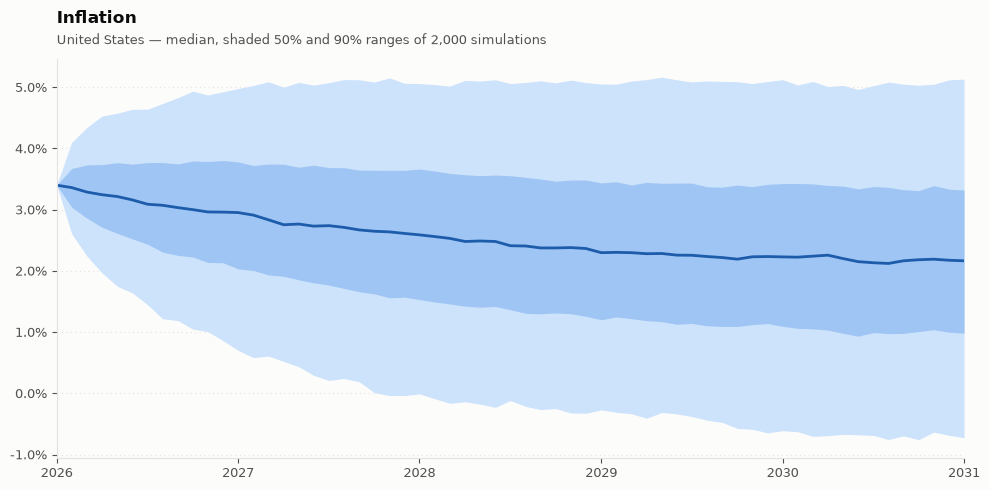

In [6]:
soft_landing_result.plot("united_states_inflation")

## Targets only: Financial Crisis

> Keep the assumptions, pick out the scenarios that tell the story.

Financial Crisis sets no beliefs. It keeps the scenarios with the weakest stocks (bottom 20%), the highest unemployment
(top 20%) and the lowest short rate (bottom 30%), one filter after the other. `library.apply(baseline, "Financial Crisis")`
narrows a run you already have without simulating again, but three filters keep only about 1% of it: some 24 of 2,000,
too few to read percentiles from. `simulate(keep=500)` instead draws about 40,000 and returns the 500 that tell the story.

In [7]:
financial_crisis = library.get("Financial Crisis")
financial_crisis_result = Scenarios.from_config(config, regime=financial_crisis).simulate(keep=500)
print(f"Financial Crisis keeps {financial_crisis_result.n_simulations} scenarios")

compare_runs(
    {"baseline": baseline, "financial_crisis": financial_crisis_result},
    factors=["us_broad", "united_states_unemployment", "united_states_short_rate"],
)

Financial Crisis keeps 500 scenarios


factor,baseline,financial_crisis
str,f64,f64
"""us_broad""",0.098426,-0.019753
"""united_states_unemployment""",0.055251,0.068686
"""united_states_short_rate""",0.029226,0.015181


## Both at once: Oil Crisis

Oil Crisis combines both: an inflation spike to 9% within a year, easing to 2.5% by year 8, and then only the scenarios
in the top 30% by short rate and bottom 30% by stock return. `library.simulate` does all of it in one call: build
the configuration, simulate it, then narrow.

In [8]:
oil_crisis_result = library.simulate(scenarios, config, "Oil Crisis")
print(f"Oil Crisis keeps {oil_crisis_result.n_simulations} scenarios")
oil_crisis_result.horizon_summary([1, 3, 5], factors=["united_states_inflation"])

Oil Crisis keeps 180 scenarios


factor,horizon,date,mean,std,q0.05,q0.25,q0.5,q0.75,q0.95
str,f64,date,f64,f64,f64,f64,f64,f64,f64
"""united_states_inflation""",1.0,2027-01-01,0.053974,0.012506,0.033614,0.044531,0.053806,0.062429,0.073985
"""united_states_inflation""",3.0,2029-01-01,0.062316,0.017146,0.035942,0.05138,0.061365,0.07183,0.090263
"""united_states_inflation""",5.0,2031-01-01,0.053762,0.017738,0.026882,0.040908,0.054013,0.065554,0.082806


## One sleeve among several: Tech Selloff

`equities`, `fx` and `credit` are lists, so a belief names one entry as `"<category>.<name>"` (`"equities.tech"`),
while a target names it plainly (`"tech"`). Tech Selloff makes only the `tech` sleeve's bad spells deeper, then keeps
the scenarios where `tech` lands in the bottom 25%: a sector story, not a market-wide one.

In [9]:
tech_selloff_result = library.simulate(scenarios, config, "Tech Selloff")
print(f"Tech Selloff keeps {tech_selloff_result.n_simulations} scenarios")
compare_runs({"baseline": baseline, "tech_selloff": tech_selloff_result}, factors=["tech", "us_broad"])

Tech Selloff keeps 500 scenarios


factor,baseline,tech_selloff
str,f64,f64
"""tech""",0.129837,-0.151413
"""us_broad""",0.098426,0.035475


## Next steps

- **`3. Portfolio`**: put a stressed run through a portfolio; `Portfolio.from_preset(oil, preset="balanced_60_40")` works on
  any `ScenarioSet`, stressed or not.
- The [regime documentation](https://www.jeroenbouma.com/projects/financescenarios/docs/regimes) lists every field
  for writing your own regime.